In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib


In [2]:
DATA_PATH = "Hydrogen Generation.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (1000, 11)


,timestamp,current_A,voltage_V,stack_temp_C,anode_p_kPa,cathode_p_kPa,water_flow_Lmin,ambient_temp_C,ambient_rh_pct,H2_flow_Nm3h,efficiency_pct
0,01-01-2025 00:00,78.389398,2.083596,52.329480,158.273684,141.386214,0.289918,28.387050,68.976584,0.021269,51.396498
1,01-01-2025 00:01,217.893299,1.930136,62.226291,198.453800,204.937882,0.239447,27.541752,42.629300,0.084966,53.377111
2,01-01-2025 00:02,180.076925,1.626048,62.213195,180.241951,206.887653,0.405983,22.166547,71.482190,0.052250,65.829540
3,01-01-2025 00:03,243.079598,1.979891,51.980295,206.340836,219.865578,0.308529,26.630993,65.196833,0.079197,48.968733
4,01-01-2025 00:04,180.040875,2.170842,60.464616,230.380489,233.275294,0.408038,25.011570,77.283677,0.049865,47.004539


### Cleaning

In [3]:
if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.drop(columns=["timestamp"])

df = df.fillna(df.median())


### Distribution plot 

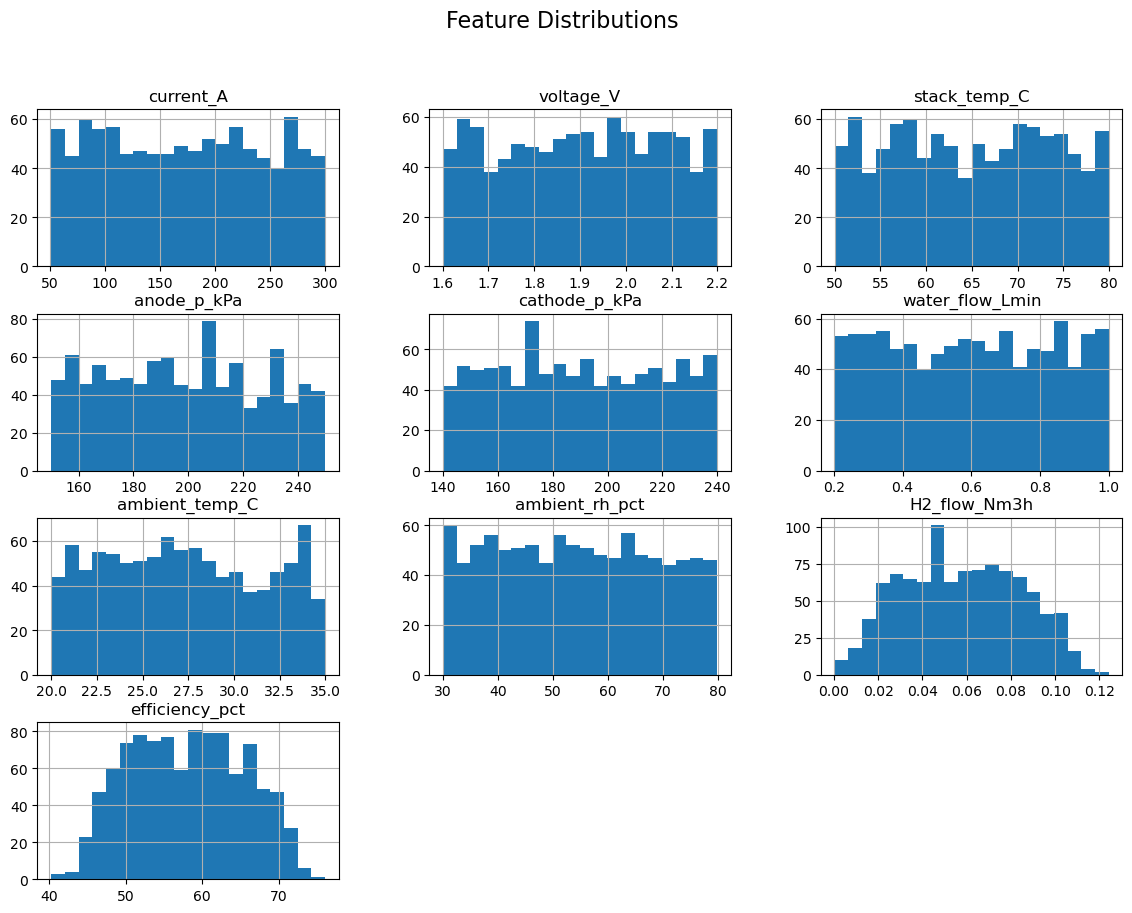

In [4]:
numeric_cols = df.select_dtypes(include=['float64','int64']).columns

df[numeric_cols].hist(figsize=(14, 10), bins=20)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()


### Correlation heatmap

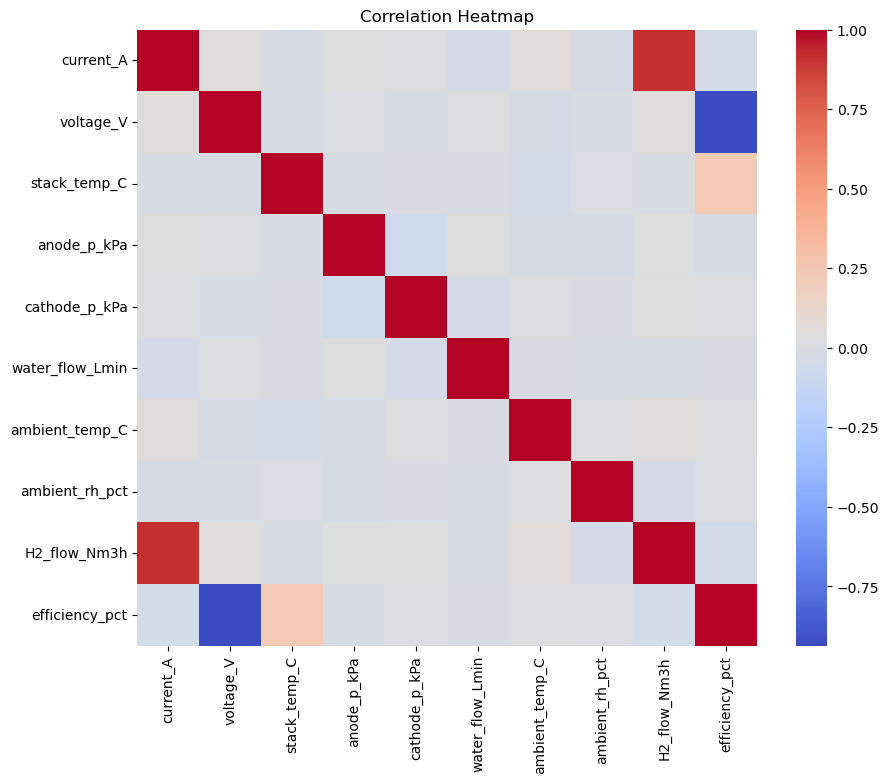

In [5]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()


### SELECTING FEATURES & TARGETS

In [6]:
target_cols = ["H2_flow_Nm3h", "efficiency_pct"]
feature_cols = [c for c in df.columns if c not in target_cols]

X = df[feature_cols]
y = df[target_cols]


### TRAIN TEST SPLIT

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### MULTI-OUTPUT MODEL 

In [8]:
model = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=350,
        random_state=42,
        n_jobs=-1
    )
)
# Training model
model.fit(X_train, y_train)

MultiOutputRegressor(estimator=RandomForestRegressor(n_estimators=350,
                                                     n_jobs=-1,
                                                     random_state=42))

### EVALUATION


Model Performance:

Target: H2_flow_Nm3h
MAE: 0.009097742413719394
R2 : 0.8277558662394926

Target: efficiency_pct
MAE: 1.8025072814623275
R2 : 0.9111835391563448


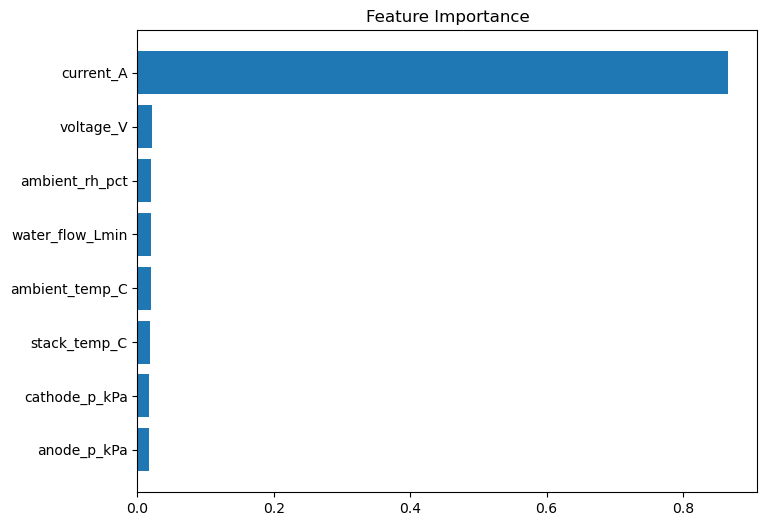

In [9]:
y_pred = model.predict(X_test)

print("\nModel Performance:")
for i, col in enumerate(target_cols):
    print(f"\nTarget: {col}")
    print("MAE:", mean_absolute_error(y_test[col], y_pred[:, i]))
    print("R2 :", r2_score(y_test[col], y_pred[:, i]))

# ---- Feature Importance ----
rf = model.estimators_[0]  # first RF
importances = rf.feature_importances_
fi = pd.DataFrame({"Feature": feature_cols, "Importance": importances})
fi = fi.sort_values("Importance", ascending=False)

plt.figure(figsize=(8,6))
plt.barh(fi["Feature"], fi["Importance"])
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

### SAVING MODEL

In [10]:
MODEL_PATH = "hydrogen_multioutput_model.joblib"

joblib.dump({
    "model": model,
    "features": feature_cols,
    "targets": target_cols
}, MODEL_PATH)

print("\nModel saved to:", MODEL_PATH)


Model saved to: hydrogen_multioutput_model.joblib


### PREDICTION FUNCTION

In [11]:
def predict_h2_and_efficiency(model_path, **kwargs):
    bundle = joblib.load(model_path)
    model = bundle["model"]
    features = bundle["features"]
    targets = bundle["targets"]

    row = []
    for f in features:
        if f not in kwargs:
            raise ValueError(f"Missing feature: {f}")
        row.append(kwargs[f])

    row = np.array(row).reshape(1, -1)
    pred = model.predict(row)[0]

    return {targets[0]: pred[0], targets[1]: pred[1]}

print("\nUse predict_h2_and_efficiency() to make predictions.")


Use predict_h2_and_efficiency() to make predictions.
